# StreamWise Energy

In [1]:
from data_loading import load_latency_data
from data_loading import load_power_data

from plot_utils import plot_ttff_vs_energy
from plot_utils import plot_ttff_vs_cost

In [2]:
from constants import DEFAULT_WORKFLOW_CONFIG

from provisioning import get_provisioning_results

In [3]:
data_dir = "data/"

## Workflow Configs and Model Profiles

In [4]:
# for a 10 minute / 600 seconds video
workflow_config = DEFAULT_WORKFLOW_CONFIG

In [5]:
latency_data = load_latency_data(data_dir=data_dir)

In [6]:
power_data = load_power_data(data_dir=data_dir)

## StreamCast Evaluation

In [7]:
from policies import STREAMWISE_POLICY
from policies import STREAMWISE_ENERGY_POLICY

In [ ]:
provisioning_streamwise = get_provisioning_results(
    workflow=workflow_config,
    latency_data=latency_data,
    power_data=power_data,
    policy=STREAMWISE_POLICY,
    verbose=False,
)

streamwise policy:   0%|          | 0/18370 [00:00<?, ?it/s]

In [ ]:
provisioning_streamwise_energy = get_provisioning_results(
    workflow=workflow_config,
    latency_data=latency_data,
    power_data=power_data,
    policy=STREAMWISE_ENERGY_POLICY,
    verbose=False,
)

streamwise energy policy:   0%|          | 0/18370 [00:00<?, ?it/s]

## Plot

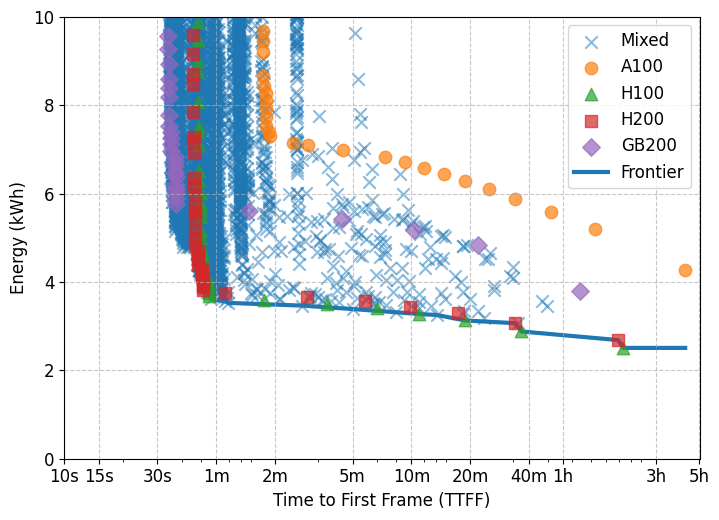

In [ ]:
plot_ttff_vs_energy(
    ttff_list=provisioning_streamwise.ttffs,
    energy_list=provisioning_streamwise.energies,
    actual_provision=provisioning_streamwise.actual_provision,
    ymax=10,
    xmin=10,
    xmax=5 * 60 * 60,
)

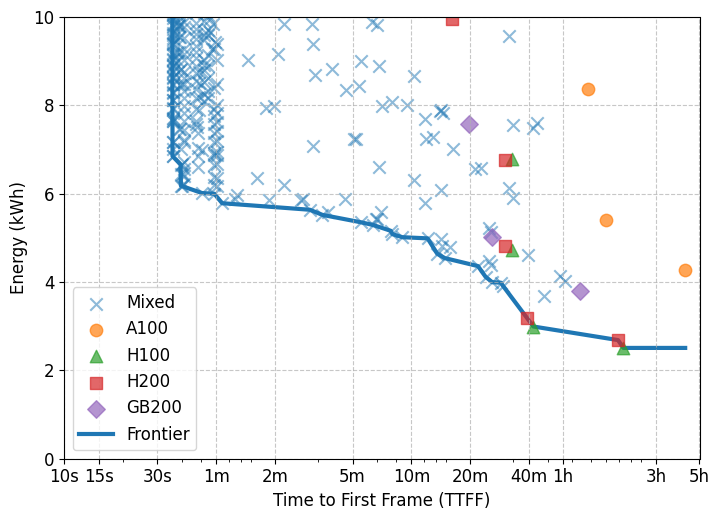

In [ ]:
plot_ttff_vs_energy(
    ttff_list=provisioning_streamwise_energy.ttffs,
    energy_list=provisioning_streamwise_energy.energies,
    actual_provision=provisioning_streamwise_energy.actual_provision,
    ymax=10,
    xmin=10,
    xmax=5 * 60 * 60,
)

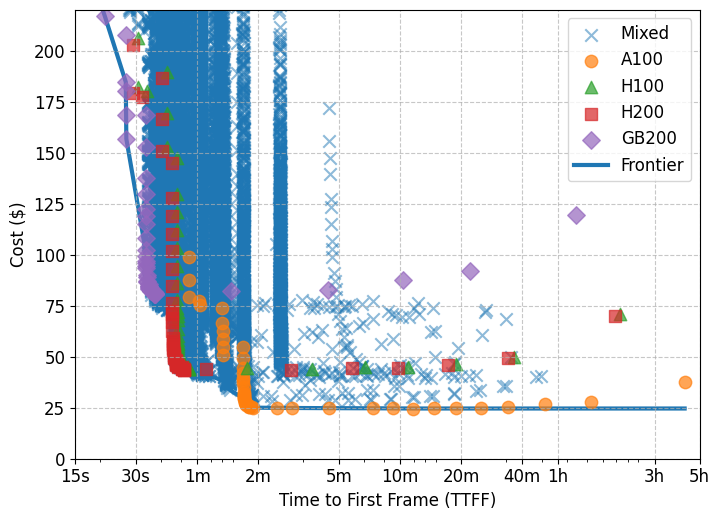

In [ ]:
plot_ttff_vs_cost(
    ttffs=provisioning_streamwise.ttffs,
    costs=provisioning_streamwise.costs,
    provisions=provisioning_streamwise.actual_provision,
    ymax=220,
    xmin=15,
    xmax=5 * 60 * 60,
)

## Baseline

In [ ]:
from policies import NAIVE_POLICY

provisioning_naive = get_provisioning_results(
    workflow=workflow_config,
    latency_data=latency_data,
    power_data=power_data,
    policy=NAIVE_POLICY,
    verbose=False,
)

naive policy:   0%|          | 0/55 [00:00<?, ?it/s]

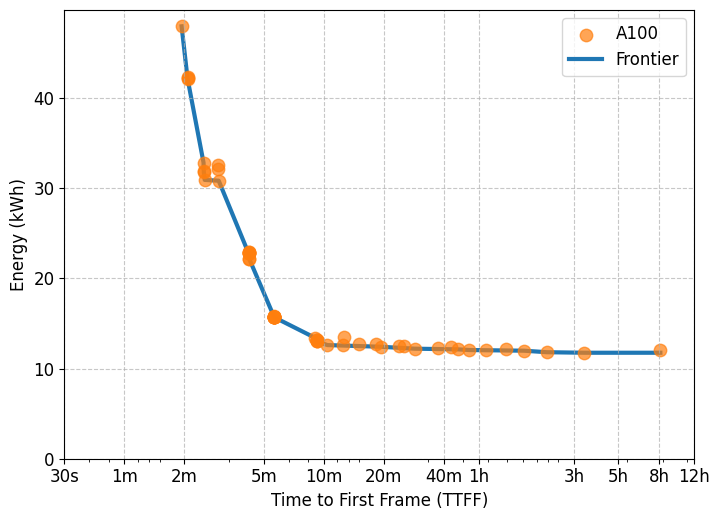

In [ ]:
plot_ttff_vs_energy(
    ttff_list=provisioning_naive.ttffs,
    energy_list=provisioning_naive.energies,
    actual_provision=provisioning_naive.actual_provision,
    # ymax=10,
    xmin=30,
    xmax=12 * 60 * 60,
)

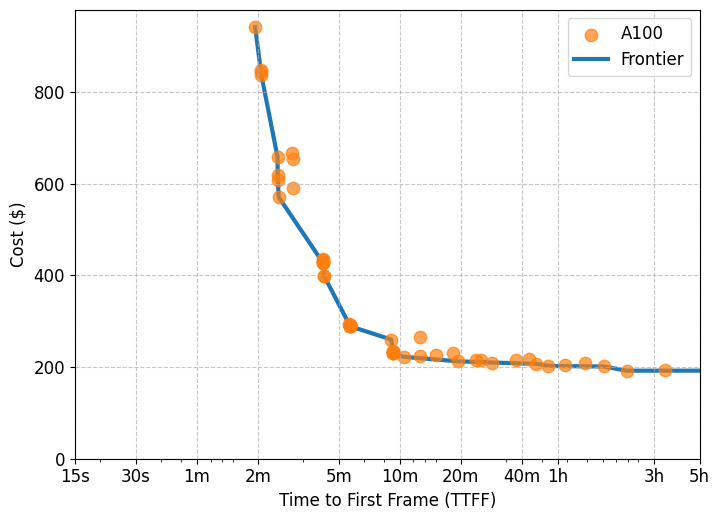

In [ ]:
plot_ttff_vs_cost(
    ttffs=provisioning_naive.ttffs,
    costs=provisioning_naive.costs,
    provisions=provisioning_naive.actual_provision,
    # ymax=220,
    xmin=15,
    xmax=5 * 60 * 60,
)